In [1]:
from pathlib import Path

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

import ml_tools as mlt
import spatial_hazard as sh
import sim_ranking as sr
import sha_calc as sha


In [30]:
db_ffp = Path("/Users/claudy/dev/work/data/sim_ranking/emp_realisations/perturbed_0313_100r/gm_db_emp.sqlite")
site_corr_dir = Path("/Users/claudy/dev/work/data/sim_ranking/emp_realisations/event_loth_baker_correlations")
corr_cols = mlt.array_utils.numpy_str_join("_", "corr" , np.asarray(sr.constants.PSA_KEYS))

In [3]:
db = sr.db.DB(db_ffp)

all_sites = db.get_avail_sites()
event_sites = db.get_event_sites()
events = db.get_avail_events(data_source="emp")

# Split into training and validation
seed = 50
if seed is not None:
    print(f"Using numpy random seed: {seed}")
    np.random.seed(seed)
val_int_sites = np.random.choice(all_sites, 100, replace=False)
train_sites = np.setdiff1d(all_sites, val_int_sites)

val_events = np.random.choice(events, 75, replace=False)
train_events = np.setdiff1d(events, val_events)

station_df = db.get_site_df()
dist_matrix = sh.im_dist.calculate_distance_matrix(all_sites, station_df)

Using numpy random seed: 50


In [4]:
train_site_combs, train_event_sites = sr.ml.data.compute_site_combinations(
    event_sites,
    train_events,
    dist_matrix,
    train_sites,
    train_sites,
    max_dist=50,
)
val_site_combs, val_event_sites = sr.ml.data.compute_site_combinations(
    event_sites,
    val_events,
    dist_matrix,
    train_sites,
    val_int_sites,
    max_dist=50,
)

In [5]:
def get_sc_df(val_events, val_event_sites, val_site_combs, dist_matrix, site_corr_dir):
    events = val_events
    site_ints = []
    site_obs = []
    sc_events = [] 
    for cur_event in events:
        cur_sites = val_event_sites[cur_event]
        cur_site_combs = val_site_combs[cur_event]
        
        site_ints.append(cur_sites[cur_site_combs[:, 0]])
        site_obs.append(cur_sites[cur_site_combs[:, 1]])
        
        sc_events.append(np.repeat(cur_event, cur_site_combs.shape[0]))
        
    site_ints = np.concatenate(site_ints)
    site_obs = np.concatenate(site_obs)
    sc_events = np.concatenate(sc_events)
    
    sc_df = pd.DataFrame(
        {
            "event": sc_events,
            "site_int": site_ints,
            "site_obs": site_obs,
        }
        , dtype="category"
    )
    
    i = dist_matrix.index.get_indexer_for(sc_df["site_int"])
    j = dist_matrix.columns.get_indexer_for(sc_df["site_obs"])
    dists = dist_matrix.values[i, j]
    
    sc_df["dist"] = dists
    
    corr_cols = mlt.array_utils.numpy_str_join("_", "corr" , np.asarray(sr.constants.PSA_KEYS))
    for cur_event in events:
        cur_corrs = pd.read_pickle(site_corr_dir / f"{cur_event}.pickle")
        
        cur_site_ints = sc_df[sc_df["event"] == cur_event]["site_int"].unique()
        
        for cur_site_int in cur_site_ints:
            cur_mask = (sc_df["event"] == cur_event) & (sc_df["site_int"] == cur_site_int)
            cur_df = sc_df[cur_mask]
            a = cur_corrs.get_site_im_corrs(cur_site_int, sr.constants.PSA_KEYS).loc[cur_df["site_obs"].values]
            
            sc_df.loc[cur_mask, corr_cols] = a.values
            
    sc_df["corr_mean"] = sc_df[corr_cols].mean(axis=1)
    
    return sc_df
    

val_sc_df = get_sc_df(val_events, val_event_sites, val_site_combs, dist_matrix, site_corr_dir)
train_sc_df = get_sc_df(train_events, train_event_sites, train_site_combs, dist_matrix, site_corr_dir)

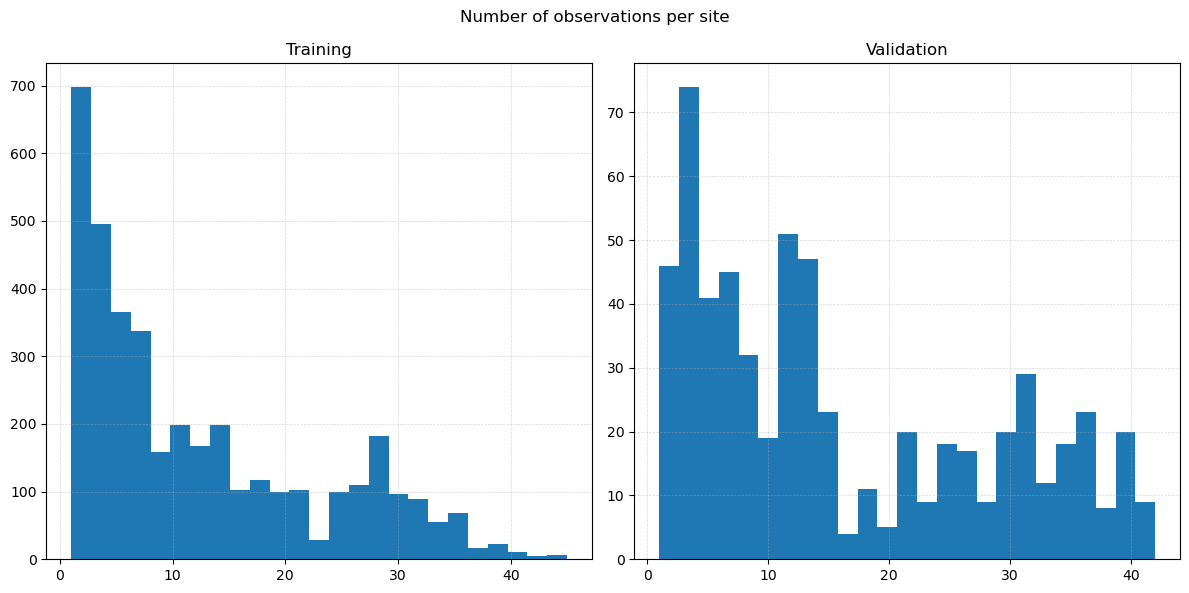

In [16]:
# Number of observations
val_n_obs = val_sc_df.groupby(["event", "site_int"], observed=True).size().values
train_n_obs = train_sc_df.groupby(["event", "site_int"], observed=True).size().values
bins = 25

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 6))

ax1.hist(train_n_obs, bins=bins)
ax1.grid(linewidth=0.5, alpha=0.5, linestyle="--")
ax1.set_title("Training")

ax2.hist(val_n_obs, bins=bins)
ax2.grid(linewidth=0.5, alpha=0.5, linestyle="--")
ax2.set_title("Validation")

fig.suptitle("Number of observations per site")
fig.tight_layout()

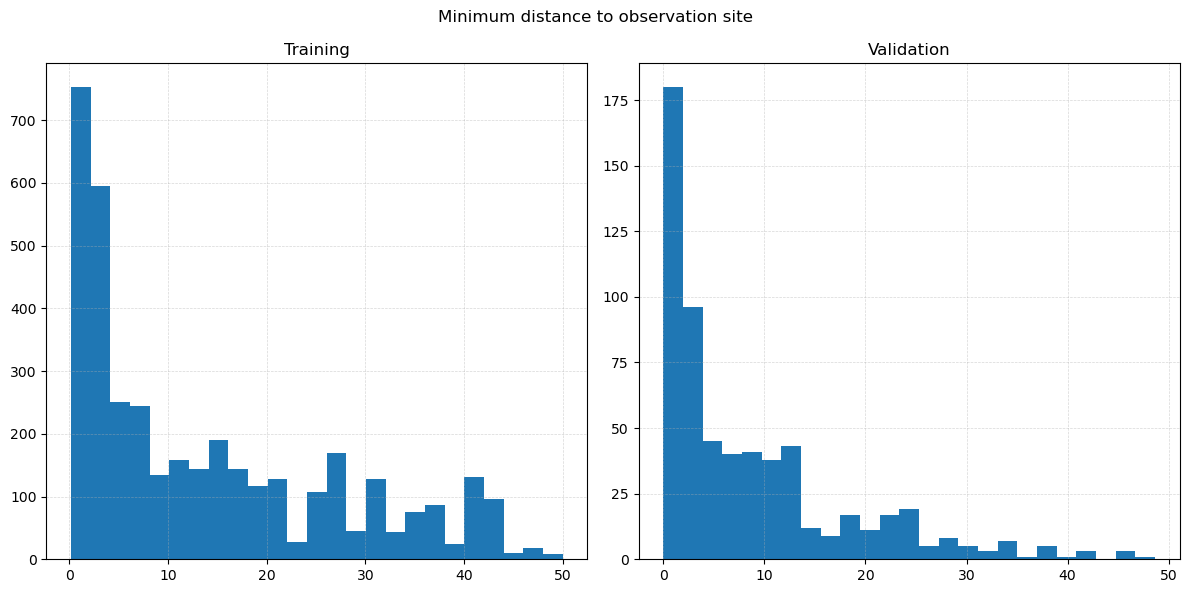

In [15]:
# Minimum distance to observation site
val_min_dist = val_sc_df.groupby(["event", "site_int"], observed=True)["dist"].min().values
train_min_dist = train_sc_df.groupby(["event", "site_int"], observed=True)["dist"].min().values
bins = 25

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 6))

ax1.hist(train_min_dist, bins=bins)
ax1.grid(linewidth=0.5, alpha=0.5, linestyle="--")
ax1.set_title("Training")

ax2.hist(val_min_dist, bins=bins)
ax2.grid(linewidth=0.5, alpha=0.5, linestyle="--")
ax2.set_title("Validation")

fig.suptitle("Minimum distance to observation site")
fig.tight_layout()

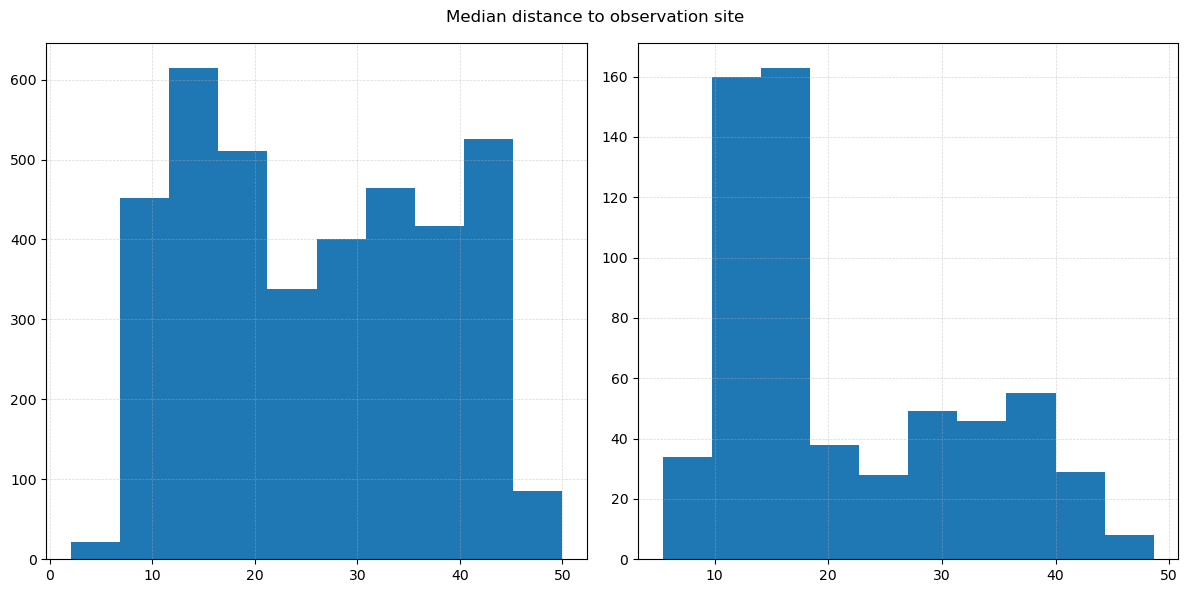

In [38]:
# Median distance to observation site
val_med_dist = val_sc_df.groupby(["event", "site_int"], observed=True)["dist"].median().values
train_med_dist = train_sc_df.groupby(["event", "site_int"], observed=True)["dist"].median().values

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 6))

ax1.hist(train_med_dist)
ax1.grid(linewidth=0.5, alpha=0.5, linestyle="--")

ax2.hist(val_med_dist)
ax2.grid(linewidth=0.5, alpha=0.5, linestyle="--")

fig.suptitle("Median distance to observation site")
fig.tight_layout()

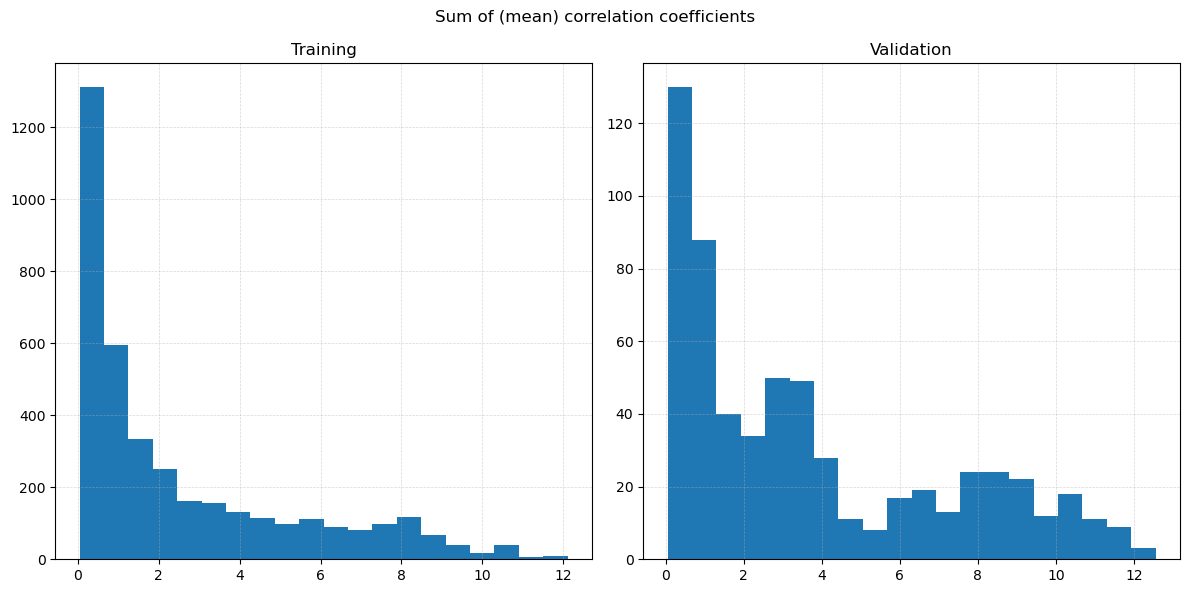

In [36]:
# Sum of correlation coefficients
val_corr_sum = val_sc_df.groupby(["event", "site_int"], observed=True)["corr_mean"].sum().values
train_corr_sum = train_sc_df.groupby(["event", "site_int"], observed=True)["corr_mean"].sum().values
bins = 20

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 6))

ax1.hist(train_corr_sum, bins=bins)
ax1.grid(linewidth=0.5, alpha=0.5, linestyle="--")
ax1.set_title("Training")

ax2.hist(val_corr_sum, bins=bins)
ax2.grid(linewidth=0.5, alpha=0.5, linestyle="--")
ax2.set_title("Validation")

fig.suptitle("Sum of (mean) correlation coefficients")
fig.tight_layout()


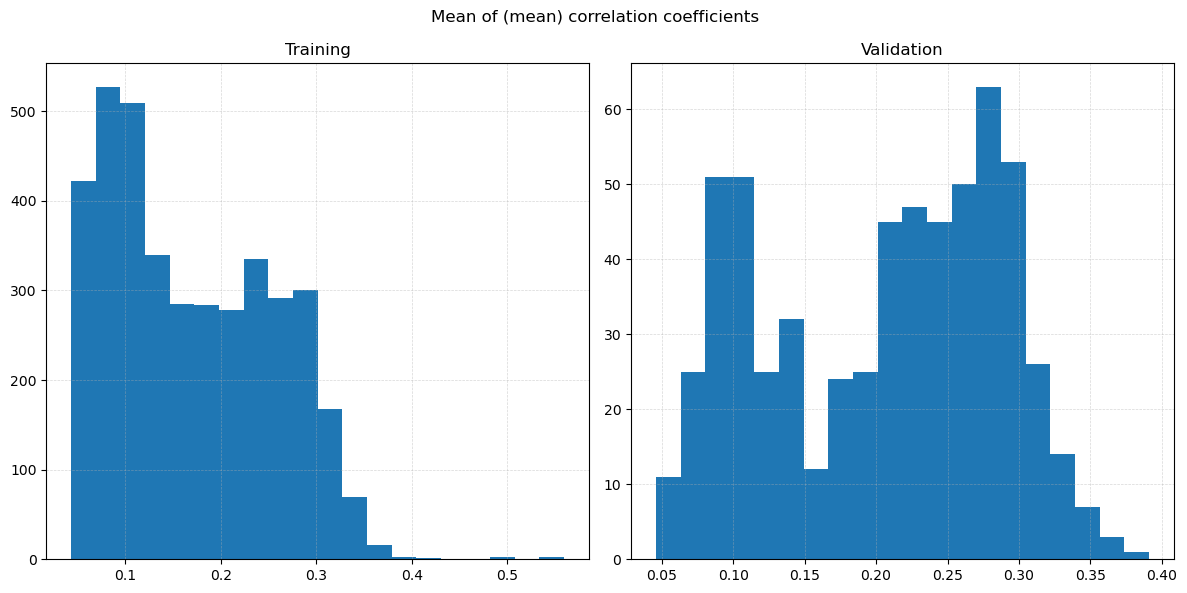

In [37]:
# Mean of correlation coefficients
val_corr_mean = val_sc_df.groupby(["event", "site_int"], observed=True)["corr_mean"].mean().values
train_corr_mean = train_sc_df.groupby(["event", "site_int"], observed=True)["corr_mean"].mean().values
bins = 20

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 6))

ax1.hist(train_corr_mean, bins=bins)
ax1.grid(linewidth=0.5, alpha=0.5, linestyle="--")
ax1.set_title("Training")

ax2.hist(val_corr_mean, bins=bins)
ax2.grid(linewidth=0.5, alpha=0.5, linestyle="--")
ax2.set_title("Validation")

fig.suptitle("Mean of (mean) correlation coefficients")
fig.tight_layout()

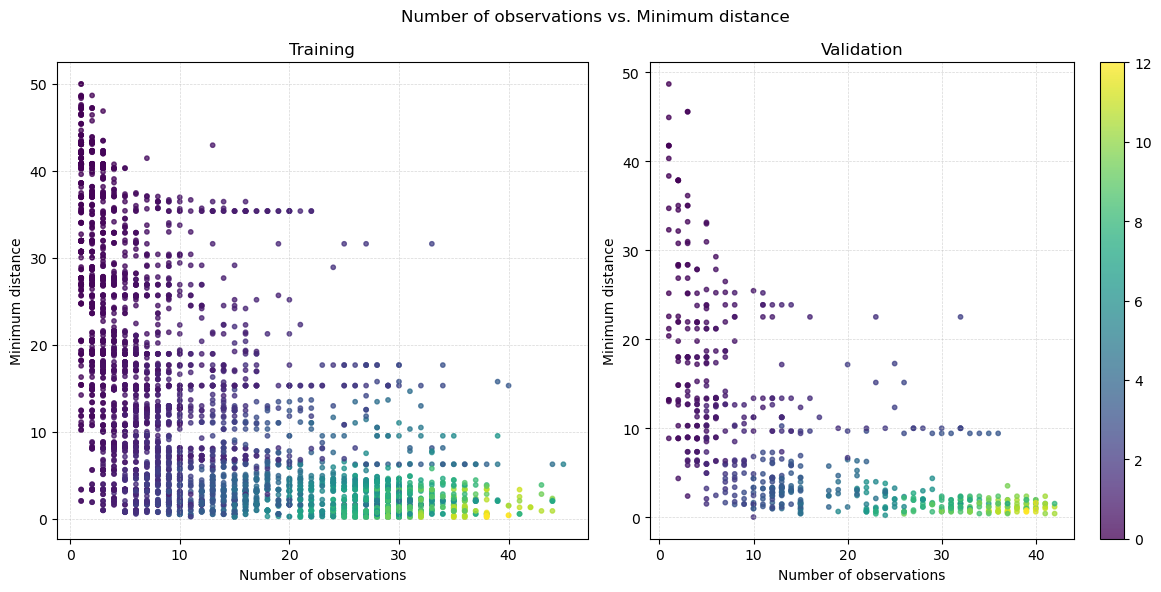

In [54]:
# Scatter - Number of observations vs. Minimum distance

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 6))

ax1.scatter(train_n_obs, train_min_dist, c=train_corr_sum, s=10, alpha=0.75, vmin=0, vmax=12)
ax1.grid(linewidth=0.5, alpha=0.5, linestyle="--")
ax1.set_xlabel("Number of observations")
ax1.set_ylabel("Minimum distance")
ax1.set_title("Training")

cm = ax2.scatter(val_n_obs, val_min_dist, c=val_corr_sum, s=10, alpha=0.75, vmin=0, vmax=12)
ax2.grid(linewidth=0.5, alpha=0.5, linestyle="--")
ax2.set_xlabel("Number of observations")
ax2.set_ylabel("Minimum distance")
ax2.set_title("Validation")

plt.colorbar(cm, ax=[ax1, ax2], label="Sum of correlation coefficients")


fig.suptitle("Number of observations vs. Minimum distance");
fig.tight_layout()

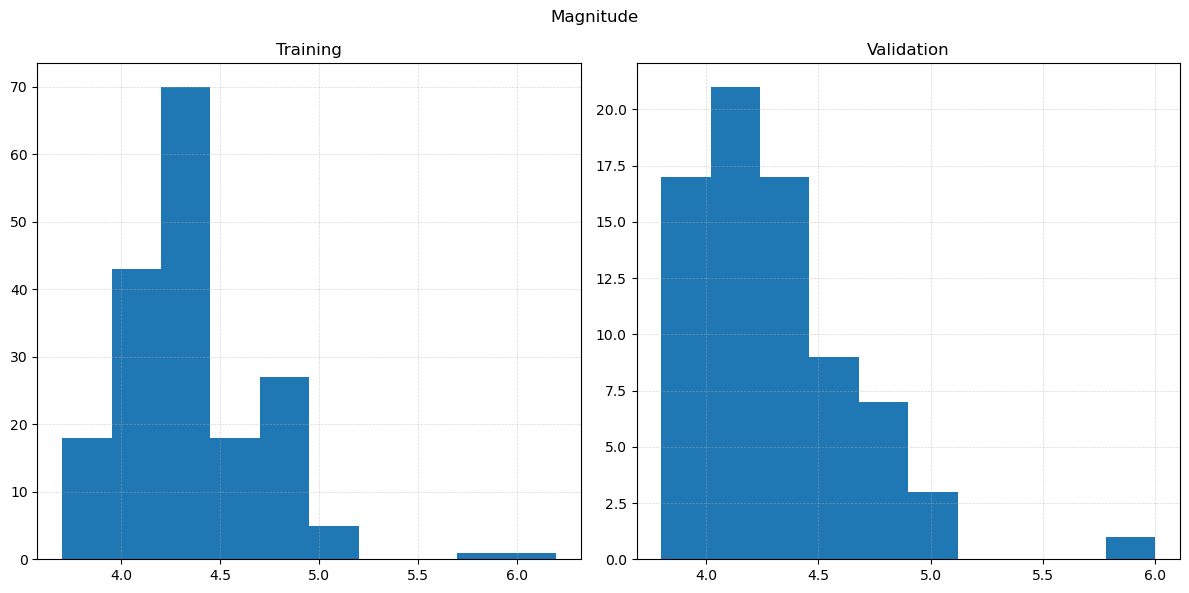

In [39]:
# Magnitude distribution
event_df = db.get_event_df()
val_event_mags = event_df.loc[val_events, "mag"].values
train_event_mags = event_df.loc[train_events, "mag"].values

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 6))

ax1.hist(train_event_mags)
ax1.grid(linewidth=0.5, alpha=0.5, linestyle="--")
ax1.set_title("Training")

ax2.hist(val_event_mags)
ax2.grid(linewidth=0.5, alpha=0.5, linestyle="--")
ax2.set_title("Validation")

fig.suptitle("Magnitude");
fig.tight_layout()

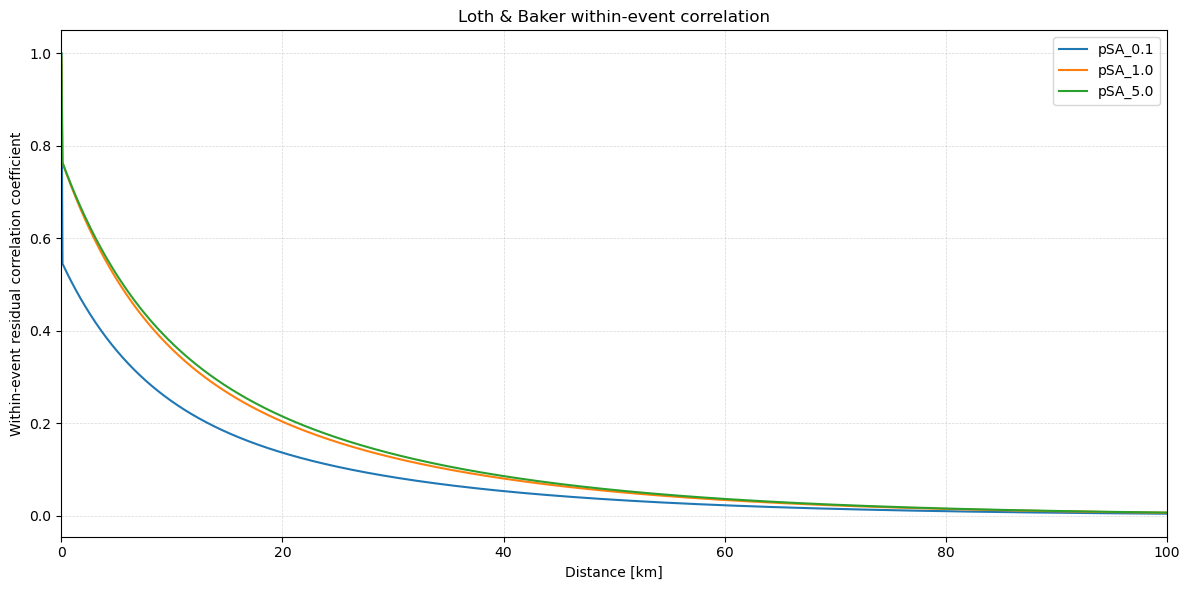

In [67]:
dist_vals = np.linspace(0, 100, 1000)
ims = ["pSA_0.1", "pSA_1.0", "pSA_5.0"]

fig = plt.figure(figsize=(12, 6))

for cur_im in ims:
    corr_vals = sha.loth_baker_corr_model.get_correlations(cur_im, cur_im, dist_vals)
    plt.plot(dist_vals, corr_vals, label=cur_im)

plt.title(f"Loth & Baker within-event correlation")
plt.xlabel(f"Distance [km]")
plt.ylabel(f"Within-event residual correlation coefficient")
plt.grid(linewidth=0.5, alpha=0.5, linestyle="--")
plt.legend()
plt.xlim(0, 100)
plt.tight_layout()


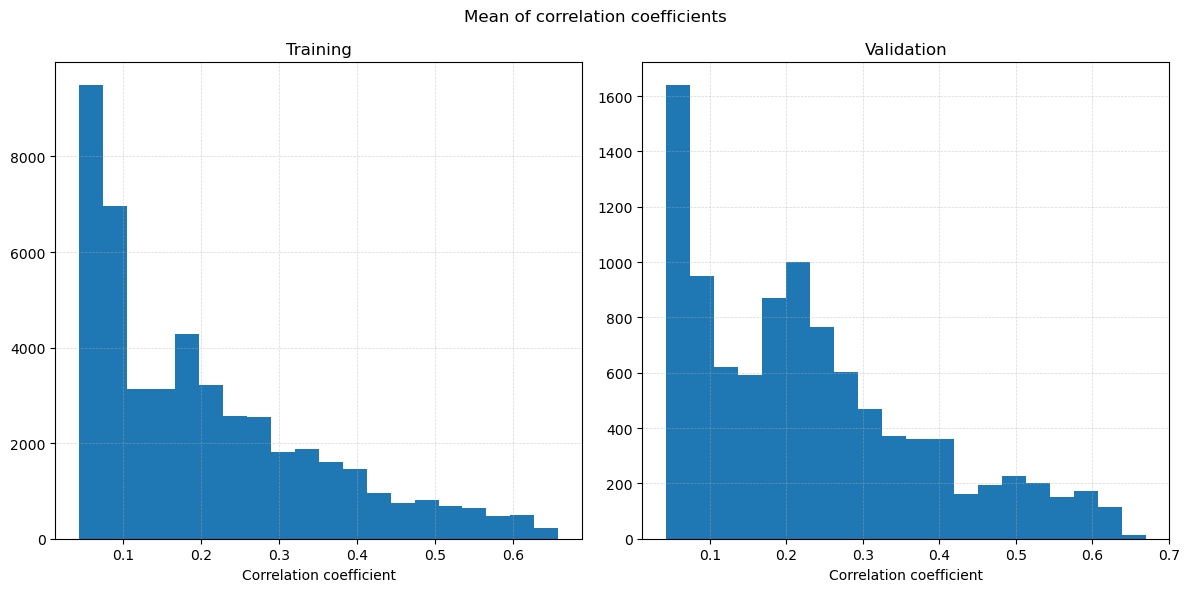

In [78]:
val_corr_values = val_sc_df["corr_mean"].values
train_corr_values = train_sc_df["corr_mean"].values
bins = 20

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 6))

ax1.hist(train_corr_values, bins=bins)
ax1.grid(linewidth=0.5, alpha=0.5, linestyle="--")
ax1.set_xlabel("Correlation coefficient")
ax1.set_title("Training")

ax2.hist(val_corr_values, bins=bins)
ax2.grid(linewidth=0.5, alpha=0.5, linestyle="--")
ax2.set_xlabel("Correlation coefficient")
ax2.set_title("Validation")

fig.suptitle("Mean of correlation coefficients")
fig.tight_layout()


0       0.175985
1       0.188588
2       0.470682
3       0.394594
4       0.228662
          ...   
9829    0.208164
9830    0.186263
9831    0.168110
9832    0.150271
9833    0.190754
Name: corr_mean, Length: 9834, dtype: float64

In [19]:
cur_sites[cur_site_combs[:, 0]]

array(['CMHS', 'CMHS', 'CMHS', 'CMHS', 'CMHS', 'CMHS', 'CMHS', 'CMHS',
       'CMHS', 'CMHS', 'CMHS', 'CMHS', 'CRLZ', 'CRLZ', 'CRLZ', 'CRLZ',
       'CRLZ', 'CRLZ', 'CRLZ', 'CRLZ', 'CRLZ', 'CRLZ', 'CRLZ', 'CRLZ',
       'DALS', 'DALS', 'DALS', 'DALS', 'DALS', 'DALS', 'DALS', 'DALS',
       'DALS', 'DALS', 'DALS', 'DALS', 'SPRS'], dtype='<U4')